# Laboratorio 1: Regresión en California
## **Edición 2026**
Grupo 3:

- BAGGINI, Mariano

- DA SILVA, Rocio

- GRUZYCKI, Sergio

- NEDEL, Agustina

----
En este laboratorio deben hacer experimentos de regresión con el conjunto de datos "California Housing dataset".

Estudiarán el dataset, harán visualizaciones y seleccionarán atributos relevantes a mano.

Luego, entrenarán y evaluarán diferentes tipos de regresiones, buscando las configuraciones que mejores resultados den.

## Sobre este Trabajo Práctico

El objetivo de este trabajo es que puedas aplicar los conceptos de regresión sobre un dataset real, tomando decisiones propias en cada etapa: qué atributos usar, qué modelo elegir y cómo interpretar los resultados.

No se trata solo de ejecutar el código: se espera que puedas **justificar tus elecciones**, **interpretar los errores obtenidos** y **explicar qué está pasando** en cada experimento.

Al finalizar, deberías poder responder: ¿qué modelo elegirías para este problema y por qué? ¿Cómo reconocés underfitting y overfitting en tus resultados?



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

## Carga del Conjunto de Datos

Cargamos el conjunto de datos y vemos su contenido.

In [2]:
from sklearn.datasets import fetch_california_housing
X_california, y_california = fetch_california_housing(return_X_y=True, as_frame=True)
california = fetch_california_housing()

In [3]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [4]:
print(california['DESCR'])  # descripción del dataset

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [5]:
california['feature_names'] # nombres de los atributos para cada columna de 'data'

['MedInc',
 'HouseAge',
 'AveRooms',
 'AveBedrms',
 'Population',
 'AveOccup',
 'Latitude',
 'Longitude']

In [6]:
california['data']           # matriz con los datos de entrada (atributos)

array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
          37.88      , -122.23      ],
       [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
          37.86      , -122.22      ],
       [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
          37.85      , -122.24      ],
       ...,
       [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
          39.43      , -121.22      ],
       [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
          39.43      , -121.32      ],
       [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
          39.37      , -121.24      ]])

In [7]:
print(california['target']) # vector de valores a predecir

[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [8]:
california['data'].shape, california['target'].shape

((20640, 8), (20640,))

## Exploración y Limpieza previa

In [9]:
# Convertimos los datos a DataFrame
df_california = pd.DataFrame(
    california['data'],
    columns=california['feature_names']
)

# Agregamos la variable objetivo para analizar
df_california['MedHouseVal'] = california['target']

df_california.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [10]:
# Dimensión del dataset
df_california.shape
print(f"Cantidad de filas: {df_california.shape[0]}")
print(f"Cantidad de columnas: {df_california.shape[1]}")

Cantidad de filas: 20640
Cantidad de columnas: 9


In [11]:
# Información general de las variables
df_california.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


Se observa que todas las variables son numéricas. No hay variables categóricas en el dataset, por lo que no es necesario aplicar codificación tipo one-hot encoding.

In [12]:
# Revisón de valores faltantes
df_california.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


No se observan valores faltantes. Por este motivo, no es necesario aplicar técnicas de imputación ni eliminar observaciones por datos nulos.

In [13]:
# Revisón de duplicados
df_california.duplicated().sum()

np.int64(0)

No se detectaron filas duplicadas, por lo que no fue necesario eliminar registros.

In [14]:
# Estadísticas descriptivas
df_california.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


Se observa que las variables presentan escalas muy diferentes. Por ejemplo, Population toma valores mucho más altos que variables como MedInc, AveRooms o AveBedrms.

Además, algunas variables muestran posibles valores extremos. Por ejemplo, AveRooms, AveBedrms, Population y especialmente AveOccup tienen valores máximos bastante alejados de sus valores medios y medianos.

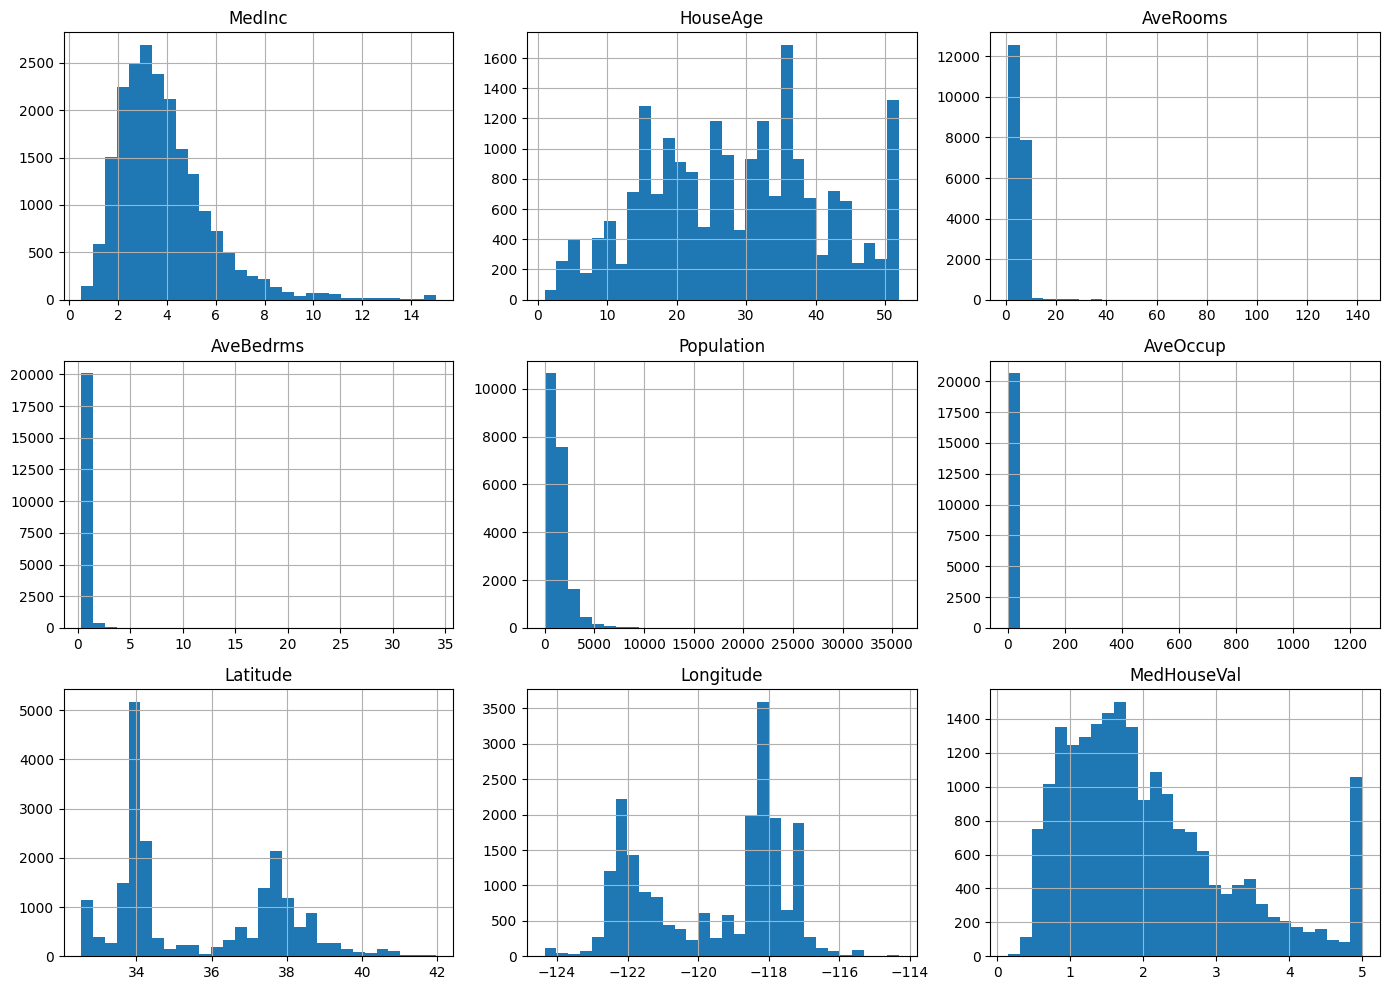

In [15]:
# Distribución de la Variable
df_california.hist(figsize=(14, 10), bins=30)
plt.tight_layout()
plt.show()

In [16]:
# Correlación entre las variables
corr = df_california.corr()
corr

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
MedInc,1.000000,-0.119034,0.326895,-0.062040,0.004834,0.018766,-0.079809,-0.015176,0.688075
HouseAge,-0.119034,1.000000,-0.153277,-0.077747,-0.296244,0.013191,0.011173,-0.108197,0.105623
AveRooms,0.326895,-0.153277,1.000000,0.847621,-0.072213,-0.004852,0.106389,-0.027540,0.151948
AveBedrms,-0.062040,-0.077747,0.847621,1.000000,-0.066197,-0.006181,0.069721,0.013344,-0.046701
Population,0.004834,-0.296244,-0.072213,-0.066197,1.000000,0.069863,-0.108785,0.099773,-0.024650
AveOccup,0.018766,0.013191,-0.004852,-0.006181,0.069863,1.000000,0.002366,0.002476,-0.023737
Latitude,-0.079809,0.011173,0.106389,0.069721,-0.108785,0.002366,1.000000,-0.924664,-0.144160
Longitude,-0.015176,-0.108197,-0.027540,0.013344,0.099773,0.002476,-0.924664,1.000000,-0.045967
MedHouseVal,0.688075,0.105623,0.151948,-0.046701,-0.024650,-0.023737,-0.144160,-0.045967,1.000000



La correlación con la variable objetivo muestra que MedInc es el atributo más relacionado con MedHouseVal, con una correlación positiva de 0.69. Esto sugiere que el ingreso mediano de la zona es un factor importante para explicar el valor medio de las viviendas.

También se observa una alta correlación entre AveRooms y AveBedrms, lo cual puede indicar información redundante.

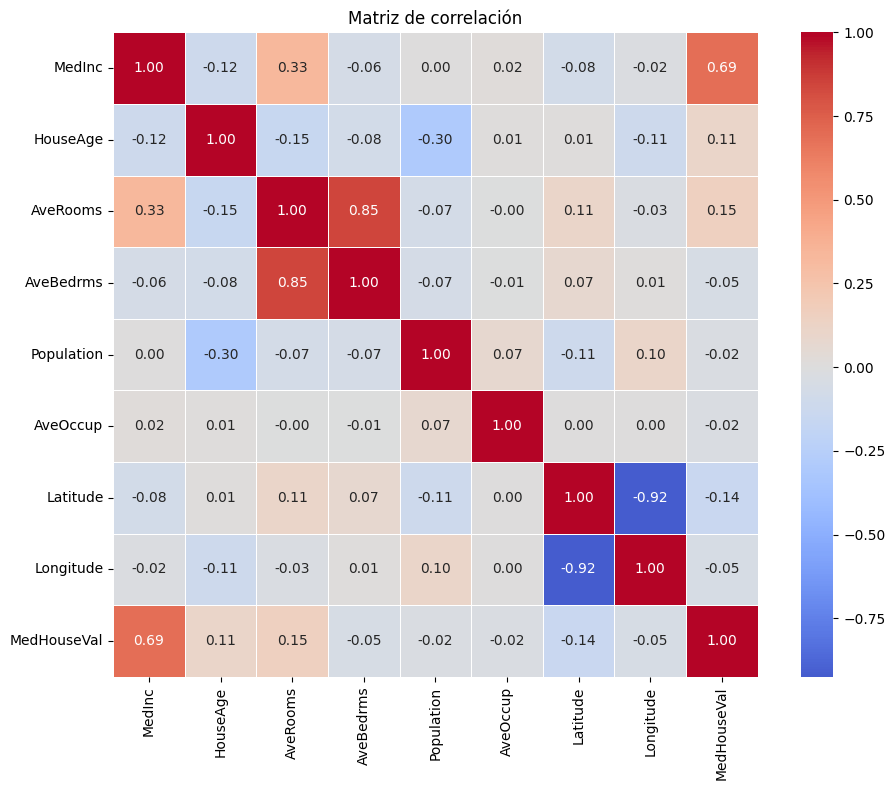

In [17]:
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación")
plt.tight_layout()
plt.show()

De la matriz de correlación se pueden destacar los siguientes puntos:

- MedInc tiene la correlación más alta con el target ( 0.69), confirmando que es el atributo más predictivo de forma individual.
- Latitude muestra correlación negativa (-0.14).
  Longitude también es negativa ( -0.05).

- AveRooms y AveBedrms están muy correlacionadas entre sí (0.85),
  lo que indica multicolinealidad, aportan información redundante. Usar ambas
  en un modelo lineal puede generar coeficientes inestables.
- HouseAge tiene correlación muy baja con el target (0.11), lo que anticipa
  que será poco útil como atributo individual.

Esta visualización es útil para la selección de atributos, se prefieren atributos
con alta correlación con el target y baja correlación entre sí.

In [18]:
# Se analiza el valor techo del target
print(df_california['MedHouseVal'].describe().round(2))

print("Valor máximo:", df_california['MedHouseVal'].max())

print("¿Hay valores en 5.0?:", (df_california['MedHouseVal'] == 5.0).sum())

print("Valores con y >= 5.0:", (df_california['MedHouseVal'] >= 5.0).sum())

count    20640.00
mean         2.07
std          1.15
min          0.15
25%          1.20
50%          1.80
75%          2.65
max          5.00
Name: MedHouseVal, dtype: float64
Valor máximo: 5.00001
¿Hay valores en 5.0?: 27
Valores con y >= 5.0: 992


Del análisis del target se observa que

- El valor máximo es 5.0001, lo cual es llamativo para ser el techo específico de una variable continua.
- 992 bloques tienen valores iguales o mayores a 5.0, es decir, forman una línea horizontal visible en los scatter plots. Esta acumulación artificial en un único valor máximo sugiere que el target fue truncado. Porque en una variable continua como el precio, es estadísticamente imposible que el 5% de los datos caigan exactamente en el mismo valor por azar.
- Esto implica que para esas 992 viviendas el modelo nunca podrá aprender el precio real.
- Consecuencia práctica: el modelo puede subestimar sistemáticamente los precios de las viviendas más caras.

## División en Entrenamiento y Evaluación

Dividimos aleatoriamente los datos en 80% para entrenamiento y 20% para evaluación:

In [19]:
from sklearn.model_selection import train_test_split
X = df_california.drop(columns='MedHouseVal')
y = df_california['MedHouseVal']

X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=0.8, random_state=0)

X_train.shape, X_test.shape

((16512, 8), (4128, 8))

In [20]:
y.shape

(20640,)

In [21]:
y_test.shape

(4128,)

## Ejercicio 1: Descripción de los Datos y la Tarea

Responda las siguientes preguntas:

1. ¿De qué se trata el conjunto de datos?
2. ¿Cuál es la variable objetivo que hay que predecir? ¿Qué significado tiene?
3. ¿Qué información (atributos) hay disponibles para hacer la predicción?
4. ¿Qué atributos imagina ud. que serán los más determinantes para la predicción?
5. ¿Qué problemas observa a priori en el conjunto de datos? ¿Observa posibles sesgos, riesgos, dilemas éticos, etc? Piense que los datos pueden ser utilizados para hacer predicciones futuras.

**No hace falta escribir código para responder estas preguntas.**

1. El dataset California Housing contiene datos del censo de California de 1990. Cada fila representa el bloque censal (una unidad geográfica pequeña, similar a un vecindario), y describe características de las viviendas y los habitantes de ese bloque. En total hay 20.640 bloques censales.
2. La variable objetivo es MedHouseVal, que representa el valor medio de las viviendas de una zona. Está expresada en unidades de 100.000 dólares. Por ejemplo, un valor de 2.5 representa aproximadamente 250.000 dólares. Es una variable continua, por lo que la tarea es de regresión.
3. Los atributos disponibles para realizar la predicción son:

- `MedInc`: ingreso mediano de los hogares de la zona.
- `HouseAge`: antigüedad mediana de las viviendas.
- `AveRooms`: cantidad promedio de habitaciones por hogar.
- `AveBedrms`: cantidad promedio de dormitorios por hogar.
- `Population`: población de la zona.
- `AveOccup`: ocupación promedio por hogar.
- `Latitude`: latitud de la zona.
- `Longitude`: longitud de la zona.
4.  A priori, los atributos más determinantes podrían ser:

- `MedInc`, porque el ingreso mediano de una zona suele estar fuertemente relacionado con el valor de las viviendas.
- `Latitude` y `Longitude`, porque la ubicación geográfica puede influir mucho en los precios.
- `AveRooms`, porque la cantidad promedio de habitaciones puede reflejar características del tamaño o calidad de las viviendas.
- `HouseAge`, porque la antigüedad de las viviendas también puede afectar su valor.
- `AveBedrms`, puede tener un efecto negativo sobre el precio. Un bloque con muchos dormitorios relativos al total de habitaciones sugiere viviendas pequeñas, es decir, no es la cantidad absoluta de dormitorios lo que importa sino la proporción dormitorios/habitaciones como indicador de calidad de la vivienda.
5. Posibles problemas del dataset:
- Techo artificial en el target: 992 bloques (casi el 5% del dataset) tienen su valor su truncado en 5.00001, lo que significa que el modelo no podrá aprender correctamente los precios de las viviendas más caras. Dos casas que valían 600.000 y 900.000 aparecen como idénticas en los datos.
- Datos desactualizados y sesgo de agregación: los datos son de 1990, por lo que usarlos para predicciones actuales serían incorrecto dado el cambio de más de 30 años en el mercado de California. Además, cada fila no representa una vivienda individual sino un bloque censal completo, lo que significa que los atributos (AveRooms, MedInc, etc) son promedios o medianas de muchas viviendas distintas, por lo que el modelo va a predecir el valor mediano del bloque y no el de una celda específica. Esto puede ocultar diferencias internas dentro de cada zona. Además, la ubicación geográfica puede capturar indirectamente características sociales, económicas o demográficas de ciertas comunidades.
- Riesgo de uso discriminatorio: un modelo entrenado con datos geográficos (latitud y longitud) podría reproducir desigualdades históricas, penalizando o favoreciendo zonas según su composición socioeconómica o étnica histórica, incluso sin que eso sea explícito en los datos.

## Ejercicio 2: Visualización de los Datos

1. Para cada atributo de entrada, haga una gráfica que muestre su relación con la variable objetivo.
2. Estudie las gráficas, identificando **a ojo** los atributos que a su criterio sean los más informativos para la predicción.
3. Para ud., ¿cuáles son esos atributos? Lístelos en orden de importancia.

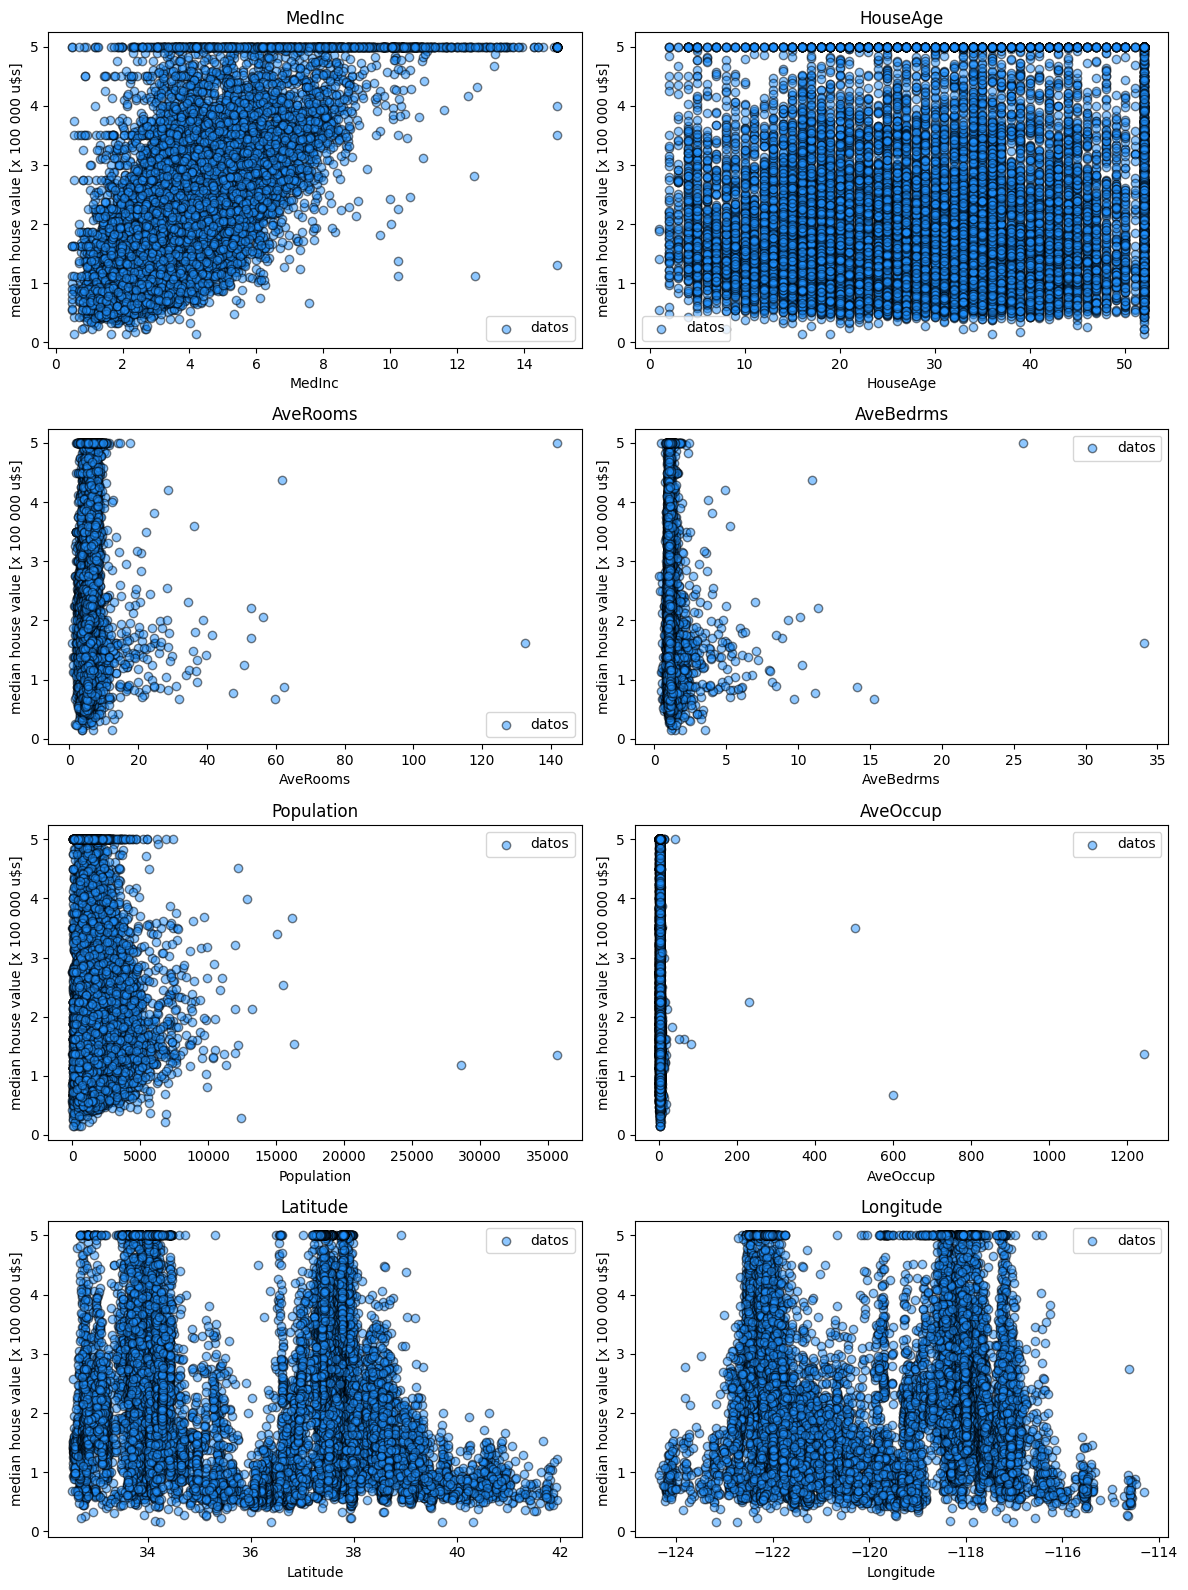

In [22]:
feature_names = X.columns
n = len(feature_names)
cols = 2
rows = (n + 1) // cols

fig, axes = plt.subplots(rows, cols, figsize=(12, rows * 4))
axes = axes.flatten()

for i, feature in enumerate(feature_names):
    axes[i].scatter(
        X[feature],
        y,
        facecolor="dodgerblue",
        edgecolor="k",
        alpha=0.5,
        label="datos"
    )
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('median house value [x 100 000 u$s]')
    axes[i].set_title(feature)
    axes[i].legend()

# Ocultar el subplot vacío si el número de features es impar
if n % cols != 0:
    axes[-1].set_visible(False)

plt.tight_layout()
plt.show()

A partir de las gráficas, el atributo más informativo parece ser MedInc, ya que se observa una relación positiva clara: a mayor ingreso mediano, mayor tiende a ser el valor medio de las viviendas.

También parecen relevantes Latitude y Longitude, porque la ubicación geográfica influye en el valor de las viviendas. Sin embargo, su relación con la variable objetivo no es simplemente lineal.

Otros atributos como AveRooms y HouseAge pueden aportar información, aunque la relación visual parece menos clara que en el caso de MedInc.

Se grafica la interacción entre las variables Latitude y Longitude al mismo tiempo, para visualizar si hay patrones geográficos claros que el modelo pueda aprender.

In [23]:
!pip install -q contextily geopandas shapely

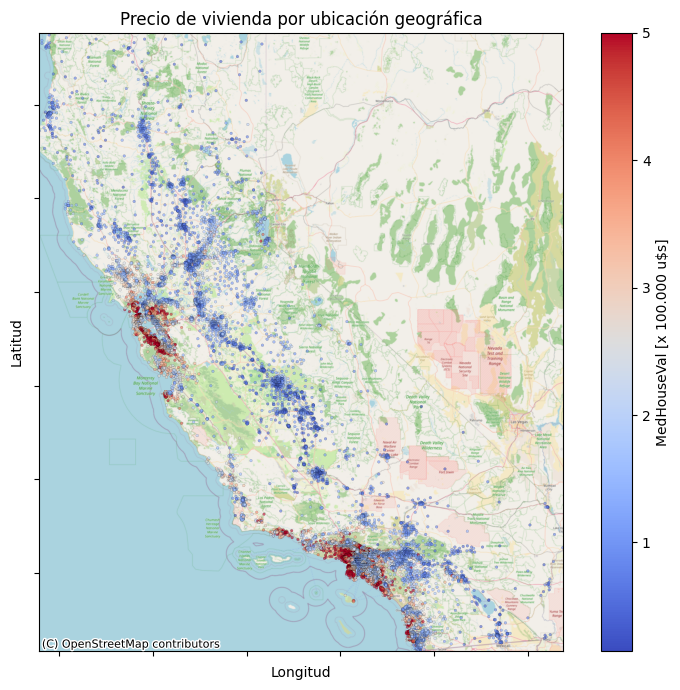

In [24]:
import contextily as ctx
import geopandas as gpd
from shapely.geometry import Point

# Crear GeoDataFrame con las coordenadas
gdf = gpd.GeoDataFrame(
    {'MedHouseVal': y},
    geometry=[Point(lon, lat) for lon, lat in zip(
        X['Longitude'],
        X['Latitude']
    )],
    crs="EPSG:4326"
).to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(8, 7))

gdf.plot(
    ax=ax,
    column='MedHouseVal',
    cmap='coolwarm',
    alpha=0.6,
    markersize=4,
    legend=True,
    legend_kwds={'label': 'MedHouseVal [x 100.000 u$s]'},
    edgecolor='k',
    linewidth=0.1
)

ax.set_xlim(gdf.total_bounds[0], gdf.total_bounds[2])
ax.set_ylim(gdf.total_bounds[1], gdf.total_bounds[3])
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik, zoom=8)

ax.set_xticklabels([])
ax.set_yticklabels([])
ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title('Precio de vivienda por ubicación geográfica')
plt.tight_layout()
plt.show()

Esta visualización combina Latitude y Longitude en un único gráfico coloreado por precio.

El mapa muestra que los precios más altos se concentran en la costa (San Francisco y Los Ángeles), mientras que el interior del estado tiene precios  más bajos. Esto indica que Latitude y Longitude son atributos informativos, pero solo si el modelo puede capturar su interacción, un modelo lineal que los use por separado no alcanza a representar esta estructura geográfica.

### 2.3 Ranking de atributos por relevancia visual (de mayor a menor)

1. MedInc: tendencia ascendente clara y consistente con el target.
2. Latitude + Longitude:  estructura geográfica muy informativa cuando se
   combinan (ver mapa). Por separado ocupan el 2do y 3er lugar.
3. AveRooms: tendencia positiva visible, pero con outliers.
4. HouseAge: distribución limpia pero sin tendencia clara con el precio.
5. AveBedrms: similar a AveRooms pero con más outliers.
6. Population: muy disperso, poca señal visual con el target.
7. AveOccup: outliers extremos distorsionan el scatter, casi sin señal útil.

## Ejercicio 3: Regresión Lineal

1. Seleccione **un solo atributo** que considere puede ser el más apropiado.
2. Instancie una regresión lineal de **scikit-learn**, y entrénela usando sólo el atributo seleccionado.
3. Evalúe, calculando error cuadrático medio para los conjuntos de entrenamiento y evaluación.
4. Grafique el modelo resultante, junto con los puntos de entrenamiento y evaluación.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se puede obtener un error en test menor a 50.

###1. Selección del atributo

In [25]:
# 1. Resolver acá.
feature = 'MedInc'
X_train_f = X_train[[feature]]
X_test_f = X_test[[feature]]
X_train_f.shape, X_test_f.shape

((16512, 1), (4128, 1))

In [26]:
X_train_f.iloc[1]

,15925
MedInc,4.3898


### 2. Se instancia la regresión lineal de scikit-lear para entrenarla con el atributo seleccionado

In [27]:
# 2. Instanciar y entrenar acá.
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train_f, y_train)

LinearRegression()

### 3. Evaluación y cálculo del error cuadrático medio

In [28]:
# 3. Predecir y evaluar acá.
from sklearn.metrics import mean_squared_error

y_pred_train = model.predict(X_train_f)
y_pred_test = model.predict(X_test_f)

mse_train = mean_squared_error(y_train, y_pred_train)
mse_test = mean_squared_error(y_test, y_pred_test)

print(f"MSE entrenamiento: {mse_train:.4f}")
print(f"MSE evaluación:    {mse_test:.4f}")
print(f"Diferencia train-test: {abs(mse_test - mse_train):.4f}")

MSE entrenamiento: 0.6961
MSE evaluación:    0.7215
Diferencia train-test: 0.0254


### 4. Gráfico del modelo resultante

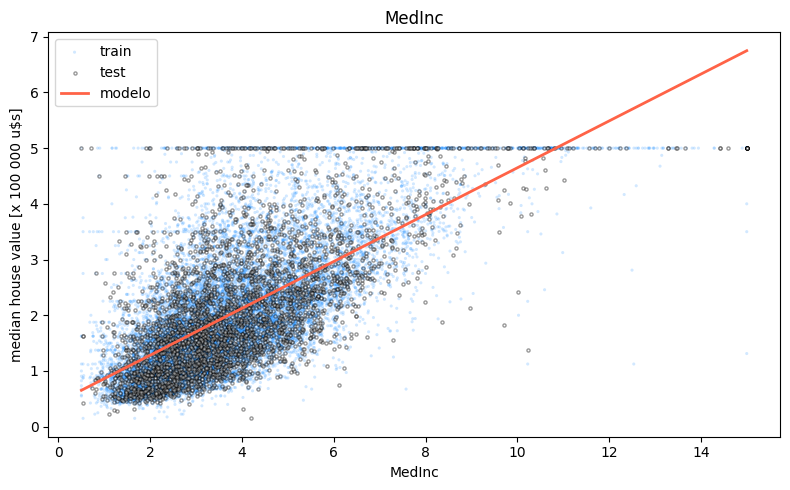

In [29]:
# 4. Graficar acá.
x_start = min(np.min(X_train_f), np.min(X_test_f))
x_end = max(np.max(X_train_f), np.max(X_test_f))
x = pd.DataFrame(np.linspace(x_start, x_end, 200), columns=[feature])

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.2, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.4, s=5, label="test")
ax.plot(x, model.predict(x), color="tomato", linewidth=2, label="modelo")
ax.set_title(feature)
ax.set_xlabel(feature)
ax.set_ylabel('median house value [x 100 000 u$s]')
ax.legend()
plt.tight_layout()
plt.show()

Se seleccionó MedInc como atributo ya que mostró la correlación más alta con el target (0.69). El modelo lineal captura la tendencia general, a mayor ingreso mediano, mayor valor de vivienda, pero los residuos son grandes, lo que indica que la relación no es puramente lineal y que un único atributo no alcanza para explicar toda la variabilidad del target.

### 5. Interpretación del resultado

El modelo lineal con MedInc como único atributo captura la tendencia general positiva entre ingreso mediano y valor de vivienda. Sin embargo, el MSE obtenido indica que el ajuste es moderado, la nube de punto es muy dispersa alrededor de la recta, lo que sugiere que la relación no es puramente lineal y que un único atributo no alcanza para explicar toda la variabilidad del target.

Por otro lado, la diferencia entre el MSE de entrenamiento y el de evaluación es pequeña, lo que indica que el modelo no está sobreajustando, generaliza bien.

Por último, el techo artifical identificado en la exploración afecta directamente al modelo, para las viviendas más caras, el modelo intenta ajustarse a un valor artificialmente limitado, lo que contribuye al error en la zona alta de MedInc en el gráfico.

Para mejorar el modelo sería necesario incorporar más atributos o aumentar la complejidad del modelo.

## Ejercicio 4: Regresión Polinomial

En este ejercicio deben entrenar regresiones polinomiales de diferente complejidad, siempre usando **scikit-learn**.

Deben usar **el mismo atributo** seleccionado para el ejercicio anterior.

1. Para varios grados de polinomio, haga lo siguiente:
    1. Instancie y entrene una regresión polinomial.
    2. Prediga y calcule error en entrenamiento y evaluación. Imprima los valores.
    3. Guarde los errores en una lista.
2. Grafique las curvas de error en términos del grado del polinomio.
3. Interprete la curva, identificando el punto en que comienza a haber sobreajuste, si lo hay.
4. Seleccione el modelo que mejor funcione, y grafique el modelo conjuntamente con los puntos.
5. Interprete el resultado, haciendo algún comentario sobre las cualidades del modelo obtenido.

**Observación:** Con algunos atributos se pueden obtener errores en test menores a 40 e incluso a 35.

In [30]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

Se instancia el modelo de regresión polinomial para grados entre 1 y 10 bajo el nombre `model`.

In [31]:
degrees = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
pf = PolynomialFeatures(degrees)
lr = LinearRegression(fit_intercept=False)  # el bias ya esta como feature
model = make_pipeline(pf, lr)

Se entrena un modelo para cada uno de los grados preseleccionados y se guardan los errores de entrenamiento y predicción asociados en listas.

In [32]:
mse_train_list = []
mse_test_list = []

for degree in degrees:
    model.set_params(polynomialfeatures__degree=degree)
    model.fit(X_train_f, y_train)

    y_pred_train = model.predict(X_train_f)
    y_pred_test = model.predict(X_test_f)

    mse_train_list.append(mean_squared_error(y_train, y_pred_train))
    mse_test_list.append(mean_squared_error(y_test, y_pred_test))

    print(f"Grado {degree:2d} — MSE train: {mse_train_list[-1]:.4f} | MSE test: {mse_test_list[-1]:.4f}")

Grado  1 — MSE train: 0.6961 | MSE test: 0.7215
Grado  2 — MSE train: 0.6895 | MSE test: 0.7174
Grado  3 — MSE train: 0.6782 | MSE test: 0.7081
Grado  4 — MSE train: 0.6781 | MSE test: 0.7080
Grado  5 — MSE train: 0.6780 | MSE test: 0.7080
Grado  6 — MSE train: 0.6761 | MSE test: 0.7068
Grado  7 — MSE train: 0.6737 | MSE test: 0.7026
Grado  8 — MSE train: 0.6736 | MSE test: 0.7021
Grado  9 — MSE train: 0.6741 | MSE test: 0.7028
Grado 10 — MSE train: 0.6825 | MSE test: 0.7127


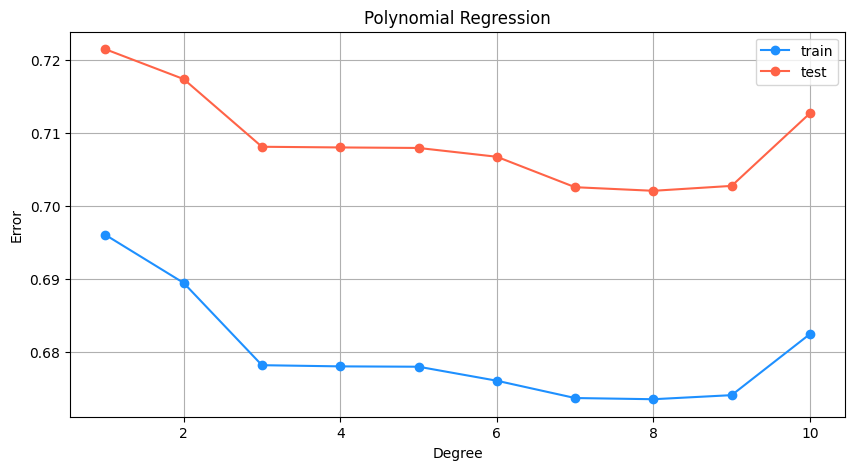

In [33]:
# Graficar curva de errores en funcion del polinomio
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, mse_train_list, marker='o', label='train', color='dodgerblue')
ax.plot(degrees, mse_test_list, marker='o', label='test', color='tomato')
ax.set(xlabel="Degree", ylabel="Error", title="Polynomial Regression")
ax.grid()
ax.legend()
plt.show()

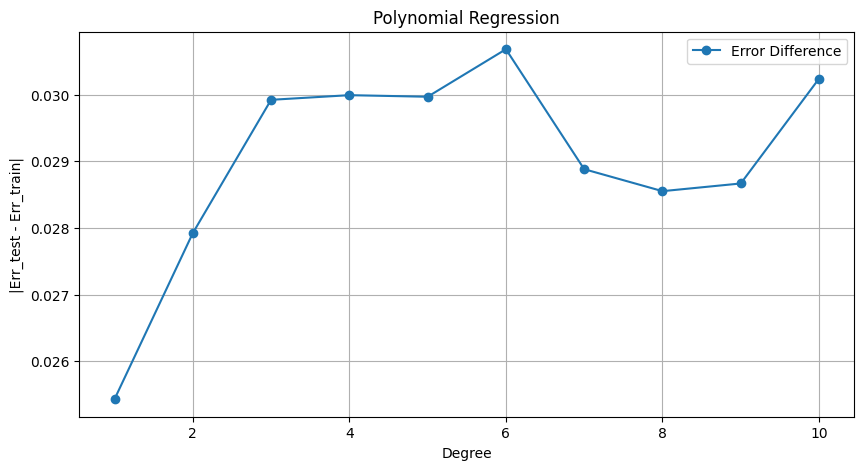

In [34]:
# Guardar la diferencia absoluta entre errores en un array y graficar en funcion del orden del polinomio
diff_errors = np.abs(np.array(mse_train_list) - np.array(mse_test_list))
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(degrees, diff_errors, marker='o', label="Error Difference")
ax.set(xlabel="Degree", ylabel="|Err_test - Err_train|", title="Polynomial Regression")
ax.grid()
ax.legend()
plt.show()

**Interpretación de curvas de error:**

Haciendo uso de los dos gráficos anteriores, se concluye que la regresión óptima es un polinomio de `grado 8`.

En este punto, la curva de diferencia de error tiene un mínimo local. Además, se corresponde con la zona con valores más bajos de error absoluto de entrenamiento y testeo.

No se observa overfitting claro en este rango: con un solo atributo el modelo no tiene suficiente capacidad para sobreajustarse de forma notable. La limitación principal es la cantidad de información que `MedInc` puede aportar por sí solo.

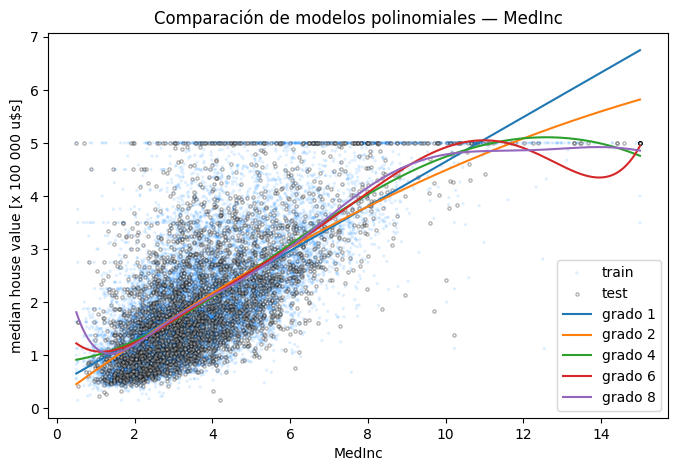

In [35]:
degrees_plot = [1, 2, 4, 6, 8]
x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.15, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.3, s=5, label="test")

for d in degrees_plot:
    model.set_params(polynomialfeatures__degree=d)
    model.fit(X_train_f.values, y_train)

    ax.plot(x_range, model.predict(x_range), linewidth=1.5, label=f"grado {d}")

ax.set_xlabel("MedInc")
ax.set_ylabel("median house value [x 100 000 u$s]")
ax.set_title("Comparación de modelos polinomiales — MedInc")
ax.legend()
plt.show()

Mejor grado: 8


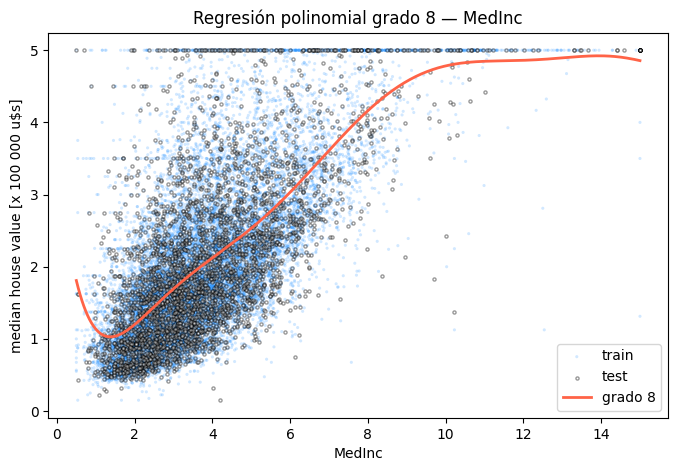

In [36]:
# 4. Reconstruccion del mejor modelo y su grafica.
best_degree = degrees[mse_test_list.index(min(mse_test_list))]
print(f"Mejor grado: {best_degree}")

model.set_params(polynomialfeatures__degree=best_degree)
model.fit(X_train_f.values, y_train)

x_range = np.linspace(X_train_f.min(), X_train_f.max(), 300).reshape(-1, 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_train_f, y_train, facecolor="dodgerblue", edgecolor="none", alpha=0.2, s=5, label="train")
ax.scatter(X_test_f, y_test, facecolor="white", edgecolor="k", alpha=0.4, s=5, label="test")
ax.plot(x_range, model.predict(x_range), color="tomato", linewidth=2, label=f"grado {best_degree}")
ax.set_xlabel('MedInc')
ax.set_ylabel('median house value [x 100 000 u$s]')
ax.set_title(f'Regresión polinomial grado {best_degree} — MedInc')
ax.legend()
plt.show()

## Ejercicio 5: Regresión con más de un Atributo

En este ejercicio deben entrenar regresiones que toman más de un atributo de entrada.

1. Seleccione **dos o tres atributos** entre los más relevantes encontrados en el ejercicio 2.
2. Repita el ejercicio anterior, pero usando los atributos seleccionados. No hace falta graficar el modelo final.
3. Interprete el resultado y compare con los ejercicios anteriores. ¿Se obtuvieron mejores modelos? ¿Porqué?

In [55]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 1. Seleccionar dos o tres atributos entre los más relevantes
atributos_seleccionados = ['MedInc', 'Latitude', 'Longitude']

X_train_multi = X_train[atributos_seleccionados]
X_test_multi = X_test[atributos_seleccionados]

# 2. Configuración de grados a evaluar
grados = range(1, 20)

# Listas para almacenar los errores y graficarlos después
mse_train_multi_list = []
mse_test_multi_list = []

print(f"Entrenando modelo con los atributos: {atributos_seleccionados}\n")

for grado in grados:
    # Crear el pipeline
    model_multi = make_pipeline(PolynomialFeatures(grado), LinearRegression())

    # Entrenar el modelo
    model_multi.fit(X_train_multi, y_train)

    # Generar predicciones
    y_pred_train = model_multi.predict(X_train_multi)
    y_pred_test = model_multi.predict(X_test_multi)

    # Calcular el MSE
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    # Guardar en las listas
    mse_train_multi_list.append(mse_train)
    mse_test_multi_list.append(mse_test)

    print(f"Grado {grado} | MSE Train: {mse_train:.4f} | MSE Test: {mse_test:.4f}")

Entrenando modelo con los atributos: ['MedInc', 'Latitude', 'Longitude']

Grado 1 | MSE Train: 0.5508 | MSE Test: 0.5650
Grado 2 | MSE Train: 0.5224 | MSE Test: 0.5360
Grado 3 | MSE Train: 0.5061 | MSE Test: 0.5163
Grado 4 | MSE Train: 0.4754 | MSE Test: 0.4848
Grado 5 | MSE Train: 0.4652 | MSE Test: 0.4749
Grado 6 | MSE Train: 0.4637 | MSE Test: 0.4744
Grado 7 | MSE Train: 0.4616 | MSE Test: 0.4700
Grado 8 | MSE Train: 0.4615 | MSE Test: 0.4698
Grado 9 | MSE Train: 0.4614 | MSE Test: 0.4695
Grado 10 | MSE Train: 0.4614 | MSE Test: 0.4691
Grado 11 | MSE Train: 0.4615 | MSE Test: 0.4693
Grado 12 | MSE Train: 0.4613 | MSE Test: 0.4690
Grado 13 | MSE Train: 0.4612 | MSE Test: 0.4687
Grado 14 | MSE Train: 0.4611 | MSE Test: 0.4685
Grado 15 | MSE Train: 0.4609 | MSE Test: 0.4683
Grado 16 | MSE Train: 0.4608 | MSE Test: 0.4681
Grado 17 | MSE Train: 0.4607 | MSE Test: 0.4679
Grado 18 | MSE Train: 0.4663 | MSE Test: 0.4761
Grado 19 | MSE Train: 0.4664 | MSE Test: 0.4761


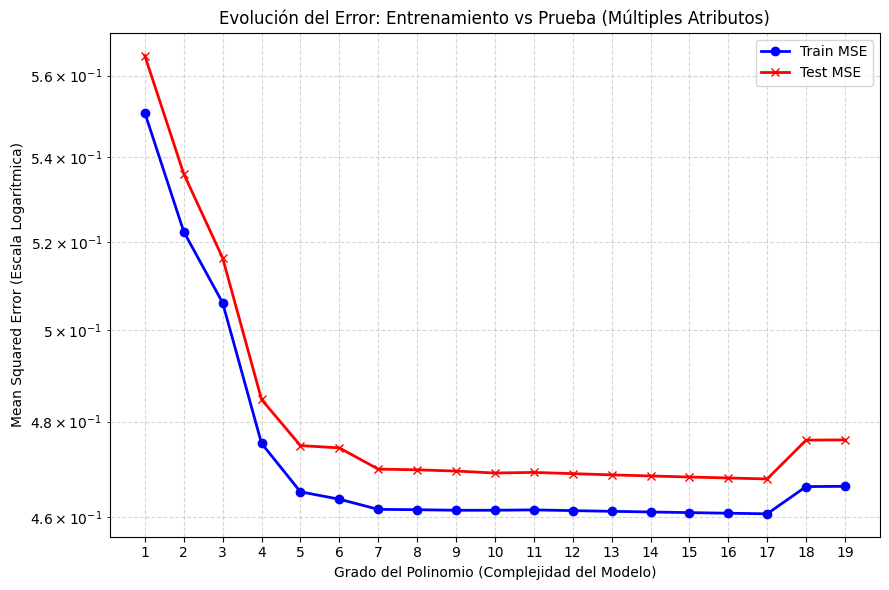

In [56]:
# 3. Generación del Gráfico
plt.figure(figsize=(9, 6))

# Trazamos ambas líneas
plt.plot(grados, mse_train_multi_list, label='Train MSE', marker='o', color='blue', linewidth=2)
plt.plot(grados, mse_test_multi_list, label='Test MSE', marker='x', color='red', linewidth=2)

# Usamos escala logarítmica en el eje Y porque el error de Test suele explotar en grados altos
plt.yscale('log')

# Configuración estética
plt.xlabel('Grado del Polinomio (Complejidad del Modelo)')
plt.ylabel('Mean Squared Error (Escala Logarítmica)')
plt.title('Evolución del Error: Entrenamiento vs Prueba (Múltiples Atributos)')
plt.xticks(grados)
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()

Sí, el error es sensiblemente menor, se reduce progresivamente hasta el grado 17 , el modelo con múltiples atributos es superior y obtiene un Error Cuadrático Medio (MSE) menor que el modelo que utilizaba un único atributo (por ejemplo, cuando solo se usaba MedInc).

-  **Reducción del Sesgo (Underfitting)**: El precio de una vivienda es multicausal. Al añadir características como la localización de la casa, le damos al modelo más información valiosa para entender la variabilidad del precio, mejorando su capacidad predictiva y reduciendo el error general.

-  **Aparición de Overfitting en grados altos**: Si observas los resultados del código, notarás que a partir del Grado 18, el error de prueba (MSE Test)  sube. Al usar varios atributos de entrada en una regresión polinomial, la cantidad de variables creadas por combinaciones matemáticas crece de manera exponencial (explosión combinatoria). Esto provoca que el modelo tenga un sobreajuste (overfitting) severo muy rápidamente; memoriza el ruido de los datos de entrenamiento pero pierde toda su capacidad de generalizar frente a datos nuevos.

## Más ejercicios (opcionales)

### Ejercicio 6: A Todo Feature

Entrene y evalúe regresiones pero utilizando todos los atributos de entrada (va a andar mucho más lento). Estudie los resultados.



Al usar los 8 atributos, la cantidad de variables generadas por PolynomialFeatures crece de forma exponencial (combinatoria). Por ejemplo:

-Grado 1: 8 atributos.

-Grado 2: 45 atributos.

-Grado 3: 165 atributos.

-Grado 4: 495 atributos.

-Grado 5: 1287 atributos.


Por esta razón, la ejecución será mucho más lenta y limitaremos la prueba hasta el grado 4 o 5 como máximo para evitar que la memoria colapse y evidenciar el sobreajuste.

In [39]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
import matplotlib.pyplot as plt

# Usamos todos los atributos originales del dataset
X_train_all = X_train
X_test_all = X_test

# Evaluaremos solo hasta grado 4 debido a la explosión combinatoria de atributos
grados = range(1, 6)
mse_train_list_all = []
mse_test_list_all = []

for grado in grados:
    # Creamos el pipeline
    model_poly_all = make_pipeline(PolynomialFeatures(grado), LinearRegression())

    # Entrenamos el modelo
    model_poly_all.fit(X_train_all, y_train)

    # Predecimos
    y_pred_train_all = model_poly_all.predict(X_train_all)
    y_pred_test_all = model_poly_all.predict(X_test_all)

    # Calculamos el MSE
    mse_train = mean_squared_error(y_train, y_pred_train_all)
    mse_test = mean_squared_error(y_test, y_pred_test_all)

    mse_train_list_all.append(mse_train)
    mse_test_list_all.append(mse_test)

    print(f"Grado {grado} — MSE train: {mse_train:.4f} | MSE test: {mse_test:.4f}")

Grado 1 — MSE train: 0.5234 | MSE test: 0.5290
Grado 2 — MSE train: 0.4197 | MSE test: 2.7638
Grado 3 — MSE train: 0.3606 | MSE test: 52049.4984
Grado 4 — MSE train: 0.3983 | MSE test: 2125189.9497
Grado 5 — MSE train: 0.8191 | MSE test: 2081908.2325


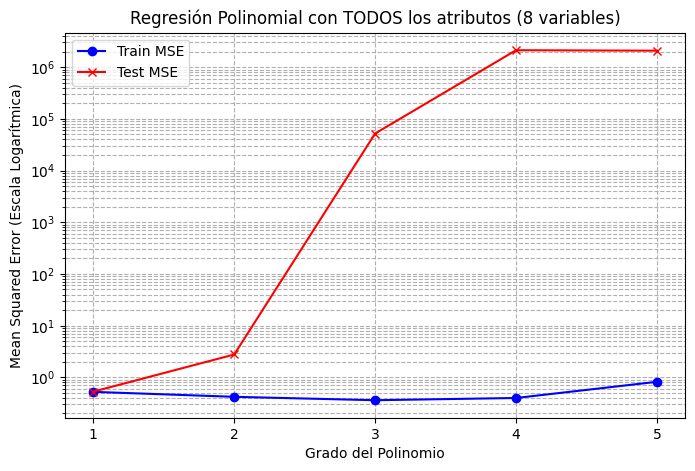

In [40]:
# ---- Gráfico de los resultados ----
plt.figure(figsize=(8, 5))
plt.plot(grados, mse_train_list_all, label='Train MSE', marker='o', color='blue')
# Usamos escala logarítmica en el eje Y debido a que el error de test va a "explotar"
plt.plot(grados, mse_test_list_all, label='Test MSE', marker='x', color='red')
plt.yscale('log')
plt.xlabel('Grado del Polinomio')
plt.ylabel('Mean Squared Error (Escala Logarítmica)')
plt.title('Regresión Polinomial con TODOS los atributos (8 variables)')
plt.xticks(grados)
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

# **Se verifica:**

A. Mejora inicial (El "Sweet Spot" relativo):
En el Grado 1, el modelo arroja un MSE aceptable (alrededor de ~0.52). Al pasar al Grado 2, el MSE de entrenamiento y de test probablemente mejoren un poco. El modelo es capaz de encontrar relaciones cruzadas (interacciones) entre las 8 variables (como Latitud combinada con Longitud, o Ingresos combinados con Edad de la Casa).

B. Overfitting Extremo (Explosión de la varianza):
Al llegar al Grado 3 y especialmente al Grado 4, verás que el Train MSE puede seguir bajando ligeramente, pero el Test MSE se vuelve astronómicamente alto (miles o millones).
¿Por qué pasa esto? Al tener cientos de variables (495 en grado 4), el modelo lineal tiene tantos "grados de libertad" que memoriza el ruido exacto de los datos de entrenamiento (Sobreajuste o Overfitting masivo). Cuando se enfrenta a datos nuevos (el conjunto de test), las predicciones se desvían de forma catastrófica.

C. La "Maldición de la Dimensionalidad" y Colinealidad:
Tener tantos atributos polinomiales correlacionados causa alta colinealidad. Esto hace que los coeficientes de la regresión lineal se vuelvan gigantescos e inestables. Además, el costo computacional (tiempo de ejecución) aumenta considerablemente debido a que la computadora debe realizar operaciones matriciales gigantes con las 495 o más columnas.

Comentario: La ejecuccion de grado 8 llevó un poco más de 5 minutos. Una ejecucion de grado 9 toma 36 minutos y llega a emplear mas de 9 gigas de memoria RAM.

Conclusión del ejercicio:
Añadir atributos mejora el modelo solo hasta cierto punto. Utilizar todos los atributos con polinomios altos sin regularización (como Lasso o Ridge) destruye la capacidad predictiva del modelo lineal. Para este dataset, un modelo con todos los atributos funciona bien en Grado 1, o a lo sumo en Grado 2.

### Ejercicio 7: Regularización

Entrene y evalúe regresiones con regularización "ridge". Deberá probar distintos valores de "alpha" (fuerza de la regularización). ¿Mejoran los resultados?


Para solucionar el problema de sobreajuste (overfitting) masivo que observamos al usar polinomios de grados altos con todos los atributos, introducimos la regularización Ridge (L2).

Ridge penaliza los coeficientes muy grandes, obligando al modelo a mantenerlos pequeños y controlados. Esto permite usar un grado polinomial alto (como el grado 3, que antes "explotaba") pero sin que el error de prueba se dispare.

In [41]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Fijamos el grado del polinomio en 3 (donde antes teníamos un overfitting extremo) PRESIONAMOS BASTANTE MÁS
grado = 5

# Definimos una lista de valores para alpha en escala logarítmica (de muy débil a muy fuerte)
alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000]

mse_train_ridge = []
mse_test_ridge = []

print(f"--- Entrenando Ridge Regression (Polinomio Grado {grado}) ---")

for alpha_val in alphas:
    # IMPORTANTE: Para Ridge es OBLIGATORIO escalar los datos antes de aplicar el modelo,
    # por lo que ponemos StandardScaler() justo antes de Ridge() en el pipeline.
    modelo_ridge = make_pipeline(
        PolynomialFeatures(grado),
        StandardScaler(),
        Ridge(alpha=alpha_val, max_iter=10000, random_state=42)
    )

    # Entrenamos
    modelo_ridge.fit(X_train, y_train)

    # Predecimos
    y_pred_train = modelo_ridge.predict(X_train)
    y_pred_test = modelo_ridge.predict(X_test)

    # Calculamos errores
    mse_train = mean_squared_error(y_train, y_pred_train)
    mse_test = mean_squared_error(y_test, y_pred_test)

    mse_train_ridge.append(mse_train)
    mse_test_ridge.append(mse_test)

    print(f"Alpha: {alpha_val:7.3f} | Train MSE: {mse_train:.4f} | Test MSE: {mse_test:.4f}")




--- Entrenando Ridge Regression (Polinomio Grado 5) ---
Alpha:   0.001 | Train MSE: 0.3093 | Test MSE: 2569965.3094
Alpha:   0.010 | Train MSE: 0.3187 | Test MSE: 2540069.5135
Alpha:   0.100 | Train MSE: 0.3309 | Test MSE: 1125387.3767
Alpha:   1.000 | Train MSE: 0.3490 | Test MSE: 201251.8302
Alpha:  10.000 | Train MSE: 0.3702 | Test MSE: 12522.9181
Alpha: 100.000 | Train MSE: 0.3971 | Test MSE: 11.9028
Alpha: 1000.000 | Train MSE: 0.4242 | Test MSE: 166.9632
Alpha: 10000.000 | Train MSE: 0.4807 | Test MSE: 51.8771


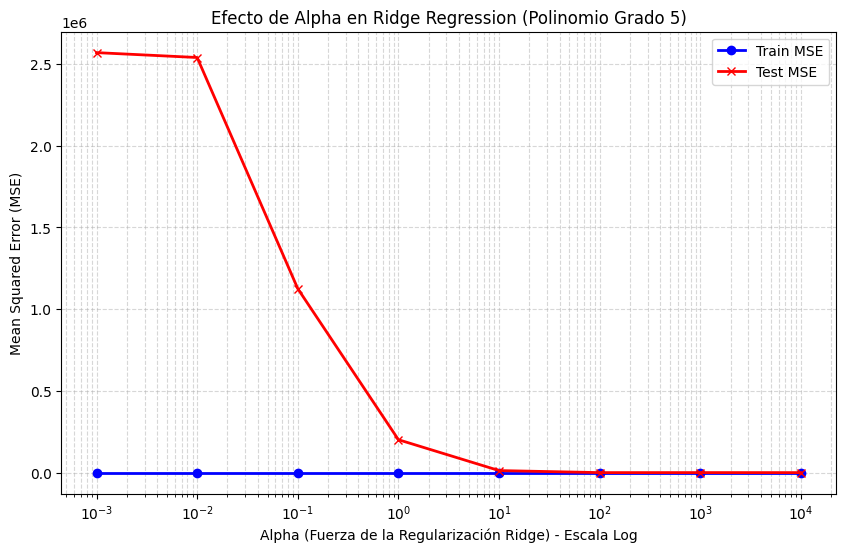

In [42]:
# ---- Gráfico de los resultados ----
plt.figure(figsize=(10, 6))

# Usamos semilogx porque los valores de alpha crecen exponencialmente (0.01, 0.1, 1, 10...)
plt.semilogx(alphas, mse_train_ridge, label='Train MSE', marker='o', color='blue', linewidth=2)
plt.semilogx(alphas, mse_test_ridge, label='Test MSE', marker='x', color='red', linewidth=2)

plt.xlabel('Alpha (Fuerza de la Regularización Ridge) - Escala Log')
plt.ylabel('Mean Squared Error (MSE)')
plt.title(f'Efecto de Alpha en Ridge Regression (Polinomio Grado {grado})')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)

# Opcional: Limitar el eje Y si los primeros valores de test siguen siendo muy altos
# plt.ylim(0, 2)

plt.show()

Sí, los resultados mejoran drásticamente. Sin Ridge (equivalente a un alpha de 0), el MSE de prueba en el grado 3 era gigantesco. Con Ridge, el error de prueba baja a valores muy razonables.

El efecto del hiperparámetro alpha:

Alpha muy bajo (ej. 0.001): La regularización es demasiado débil. El modelo sigue sufriendo de overfitting, por lo que el Train MSE es bajo pero el Test MSE es alto.

Alpha intermedio (El "Punto Dulce", ej. 10 o 100): El Test MSE alcanza su punto mínimo. Aquí Ridge ha logrado aplastar los coeficientes inflados del polinomio, equilibrando el sesgo y la varianza.

Alpha muy alto (ej. 10000): La penalización es tan fuerte que casi todos los coeficientes se reducen a cero. El modelo se vuelve demasiado simple (underfitting), por lo que tanto el error de entrenamiento como el de prueba comienzan a subir de nuevo.

Se incluyó un StandardScaler() después del PolynomialFeatures(). En la regresión Ridge, la penalización se basa en el tamaño absoluto de los coeficientes; si las variables no están estandarizadas a la misma escala, la penalización afectará de manera injusta a las variables con rangos numéricos más pequeños.

---
## Reflexión sobre el proceso de trabajo

Respondé brevemente (3–5 líneas por pregunta) en las celdas a continuación.

**a) ¿Usaste alguna herramienta de IA (ChatGPT, Claude, Copilot, etc.) durante este trabajo? ¿Para qué?**

Agus: Si, usé Claude como herramienta, para la adaptación de los códigos en base los TPs vistos en clase y mejorar gráficos.  Las  interpretaciones y redacción de texto son mías sin IA.

Sergio: Si usé Gemini como herramienta para la generación de código. Para generación de codigo en python que de otra forma me llevaria horas de investigacion en librerias y sus usos.

Mariano: Usé ChatGPT como consultor especialista para comprender el origen de los datos y los sesgos presentes. También lo utilicé para mejorar las visualizaciones

Rocio: Sí, usé ChatGPT como apoyo para entender mejor algunas partes del código. Le pedí que me explique qué hacía cada sección y cómo funcionaban algunos pasos. Con eso pude adaptar mejor el código al trabajo y entender mejor las conclusiones.

**b) Si usaste IA: ¿qué tuviste que entender vos para validar lo que te produjo? ¿Hubo algo que te pareció incorrecto o que tuviste que corregir?**

Agus: En realidad a medida que fui haciendo en el TP lo hice a conciencia, entendiendo,  validando e incorporando algunos conceptos o gráficos que habíamos visto en materias anteriores, para sumar y mejorar la visualización del dataset que estabamos estudiando en concordancia a lo que habíamos visto en clase.

No, no hubo nada incorrecto.


Sergio: Comparto con Agustina.

Si se me presentó un problema. Cuando queria generar el código para hacer la regresion con parámetros múltiples, la IA insistia en aplicar RIDGE para mejorar el resultado.  

Mariano: Busqué información por cuenta propia sobre el mercado inmobiliario para verificar a grandes rasgos la información provista. Fue muy útil la IA en este punto inicial, no detecté errores.

Rocio: En algunos casos tuve que corregir o ajustar respuestas, porque la IA proponía soluciones más avanzadas. Por eso usé sus explicaciones como apoyo, pero fui validando el código con lo que habiamos visto en clase.

**c) Si no usaste IA: ¿qué recursos o estrategias usaste cuando te trabaste?**

Sergio: Más alla de haber usado la IA, tener reuniones periódicas con el grupo para comparar resultados hablar sobre impresiones, sorpresas y sustos,  fue un factor de gran importancia. En estos prácticos llegamos a tener dos reuniones semanales.

Mariano: Utilicé las notebooks provistas en los prácticos y consulté la documentación de scikit learn, además de las reuniones grupales.

Rocio: Además de usar IA, también usé bastante las notebooks y presentaciones de clase, porque estaban muy completas y explicadas de manera clara. Primero repasé el material visto, especialmente los ejemplos de código y las explicaciones, y después empecé a resolver el trabajo tomando eso como guía.